# 1. 커피OO 데이터 분석 

## 0. 환경 설정 및 데이터 로드


In [21]:
import pandas as pd 
import csv 
import os 
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns 
import koreanize_matplotlib

In [22]:
folder_path = os.path.join(os.getcwd(), 'data')
for file in os.listdir(folder_path):
    if file.startswith('d'):
        data_path = os.path.join(folder_path, file)
        raw_data = pd.read_csv(data_path)
cp_data_df = raw_data.copy()

In [23]:
# 데이터 확인 
cp_data_df.head()

,결제일시,결제일,결제년월,결제년,결제월,결제시간,결제시간대,요일,카테고리,수량,상품별 단가,상품명_추출,Hot/Ice,원두대분류,원두종류,원두용량,할인여부,취식 방법,매출
0,2022-02-10 10:03:28,2022-02-10,2022-02,2022,2,10:03:28,10,목요일,핸드드립,1,10000,과테말라 레드 파카마라,Hot,싱글,과테말라 레드 파카마라,-,-,-,10000
1,2022-02-10 10:03:28,2022-02-10,2022-02,2022,2,10:03:28,10,목요일,핸드드립,1,10500,콜롬비아 로꼬 소르베,Ice,싱글,콜롬비아 로꼬 소르베,-,-,-,10500
2,2022-02-10 10:03:28,2022-02-10,2022-02,2022,2,10:03:28,10,목요일,핸드드립,1,12000,니카라과 COE#1,Hot,싱글,니카라과 COE#1,-,-,-,12000
3,2022-02-10 10:13:57,2022-02-10,2022-02,2022,2,10:13:57,10,목요일,에스프레소,1,6500,슈퍼클린에스프레소,Hot,블렌딩,클래식,-,-,-,6500
4,2022-02-10 10:13:57,2022-02-10,2022-02,2022,2,10:13:57,10,목요일,에스프레소,1,6500,슈퍼클린에스프레소,Hot,블렌딩,쥬시,-,-,-,6500


In [24]:
cp_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153433 entries, 0 to 153432
Data columns (total 19 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   결제일시     153433 non-null  object
 1   결제일      153433 non-null  object
 2   결제년월     153433 non-null  object
 3   결제년      153433 non-null  int64 
 4   결제월      153433 non-null  int64 
 5   결제시간     153433 non-null  object
 6   결제시간대    153433 non-null  int64 
 7   요일       153433 non-null  object
 8   카테고리     153433 non-null  object
 9   수량       153433 non-null  int64 
 10  상품별 단가   153433 non-null  int64 
 11  상품명_추출   153433 non-null  object
 12  Hot/Ice  153433 non-null  object
 13  원두대분류    153433 non-null  object
 14  원두종류     153433 non-null  object
 15  원두용량     153433 non-null  object
 16  할인여부     153433 non-null  object
 17  취식 방법    153433 non-null  object
 18  매출       153433 non-null  int64 
dtypes: int64(6), object(13)
memory usage: 22.2+ MB


In [25]:
cp_data_df.shape

(153433, 19)

In [26]:
# 주말여부 컬럼 추가 
cp_data_df['주말 여부'] = np.where(cp_data_df['요일'].isin(['토요일', '일요일']), '주말', '평일')

# 계절 컬럼 추가 
cp_data_df['계절'] = np.where(cp_data_df['결제월'].isin([12, 1, 2]), '겨울',
                        np.where(cp_data_df['결제월'].isin([3, 4, 5]), '봄',
                        np.where(cp_data_df['결제월'].isin([6, 7, 8]), '여름', '가을')))

# 카페 운영시간 9시~18시 외 데이터 제거 
cp_data_df = cp_data_df.loc[~(cp_data_df['결제시간대'].isin([7, 8, 19, 18]))]

# "시" 단위 추가
cp_data_df['결제시간대'] = cp_data_df['결제시간대'].astype(str) + '시'

In [27]:
# 컬러 
sns.color_palette("Set3")

[(0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
 (1.0, 1.0, 0.7019607843137254),
 (0.7450980392156863, 0.7294117647058823, 0.8549019607843137),
 (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
 (0.5019607843137255, 0.6941176470588235, 0.8274509803921568),
 (0.9921568627450981, 0.7058823529411765, 0.3843137254901961),
 (0.7019607843137254, 0.8705882352941177, 0.4117647058823529),
 (0.9882352941176471, 0.803921568627451, 0.8980392156862745),
 (0.8509803921568627, 0.8509803921568627, 0.8509803921568627),
 (0.7372549019607844, 0.5019607843137255, 0.7411764705882353),
 (0.8, 0.9215686274509803, 0.7725490196078432),
 (1.0, 0.9294117647058824, 0.43529411764705883)]

In [28]:
# 컬러 [파란색, 주황색]
colors1 = []
colors1.append(sns.color_palette("Set3")[5])
colors1.append(sns.color_palette("Set3")[4])

## 1-1. 카페 운영 시간과 매출의 관계 분석

### 1. 카페 월별 매출 추이

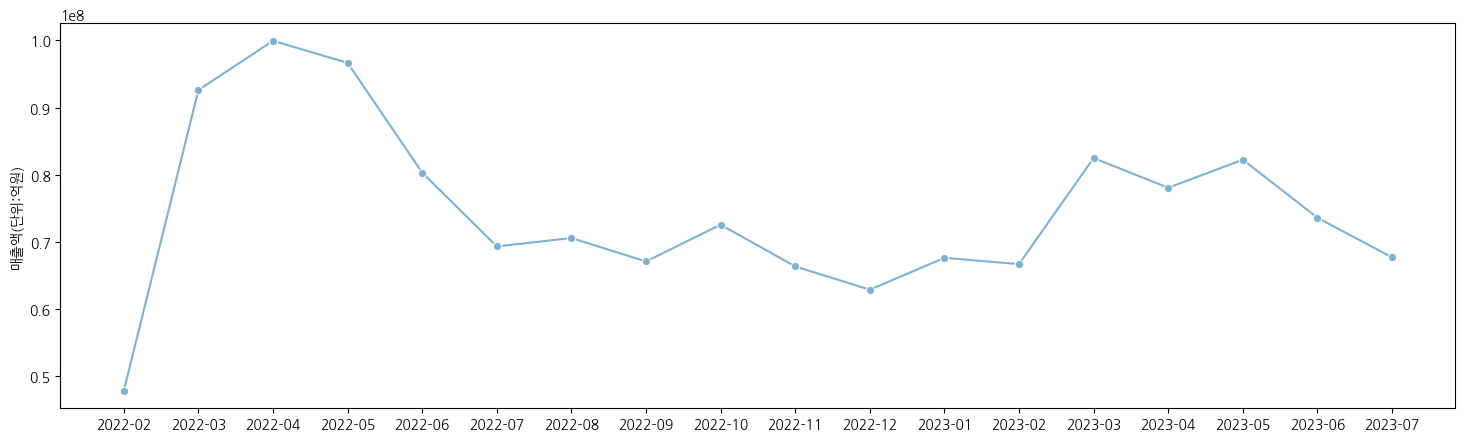

In [29]:
# 카페 월별 매출 추이
# 결제년월 기준으로 전체 매출을 합산해 월 단위 매출 흐름을 확인한다.
monthly_rev = cp_data_df.groupby(['결제년월'])['매출'].sum().reset_index(name='revenue')

# 월별 매출 추이 시각화
# x축은 월, y축은 월별 총매출이며 선 그래프로 매출 증감 흐름을 표현한다.
plt.figure(figsize=(18, 5))
sns.lineplot(data=monthly_rev, x='결제년월', y='revenue', marker='o', color=colors1[1])

plt.xlabel('')
plt.ylabel('매출액(단위:억원)')
plt.show()

### 2. 카페 시간대별 매출 추이 

#### 2-1. 카페 시간대별 누적 매출액 변화

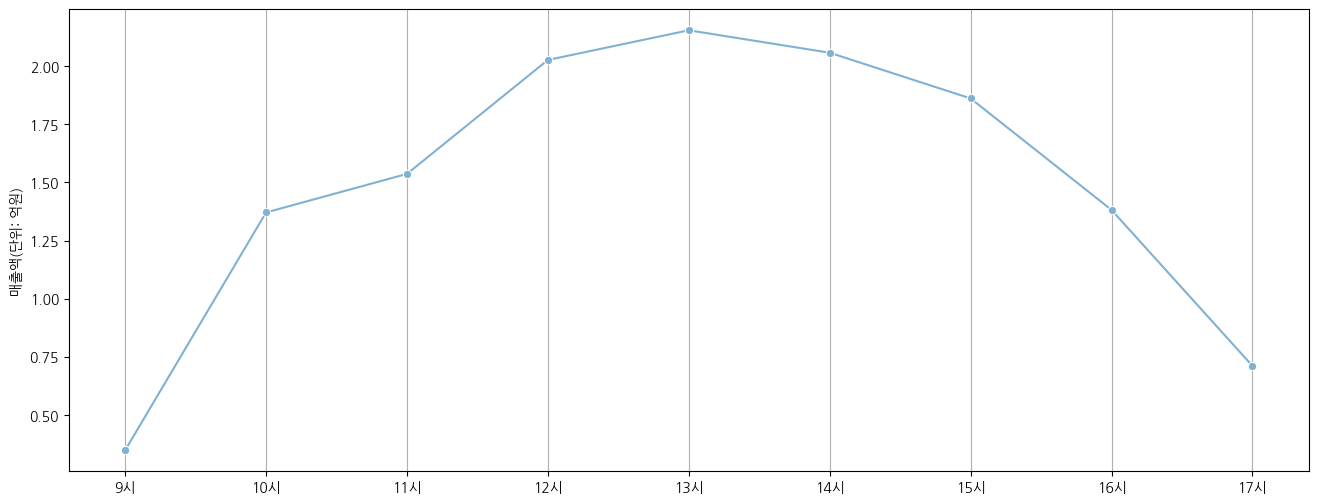

In [30]:
# 카페 시간대별 누적 매출
# 결제시간대별 전체 매출을 합산해 어느 시간대에 매출이 집중되는지 확인한다.
hourly_rev = cp_data_df.groupby('결제시간대')['매출'].sum().reset_index(name='매출')

# 시간대 순서 정의
# 문자열 시간대가 그래프에서 실제 영업시간 순서대로 표시되도록 순서를 지정한다.
hour_order = ['9시', '10시', '11시', '12시', '13시', '14시', '15시', '16시', '17시', '18시']
hourly_rev['결제시간대'] = pd.Categorical(hourly_rev['결제시간대'], categories=hour_order, ordered=True)

# 시간대 순서대로 정렬
hourly_rev = hourly_rev.sort_values('결제시간대')

# 그래프 해석을 쉽게 하기 위해 매출 단위를 원에서 억원으로 변환
hourly_rev['매출'] = hourly_rev['매출'] / 1e8

# 시간대별 누적 매출 시각화
plt.figure(figsize=(16, 6))
sns.lineplot(data=hourly_rev, x='결제시간대', y='매출', marker='o', color=colors1[1])

plt.xlabel('')
plt.ylabel('매출액(단위: 억원)')
plt.grid(axis='x')
plt.show()

In [31]:
# 시간대별 누적 매출 해석 메모
# 메인 영업 시간대의 평균 매출과 오픈/마감 시간대 매출을 비교해 운영시간 조정 가능성을 확인한다.
# 메인 시간대 평균 매출 = 202,533,975
# 오픈시간(9시)  매출 == 34,744,800
# 마감시간(17시) 매출 == 71,079,400

#### 2-2. 카페 평일/주말 시간대별 매출 변화 

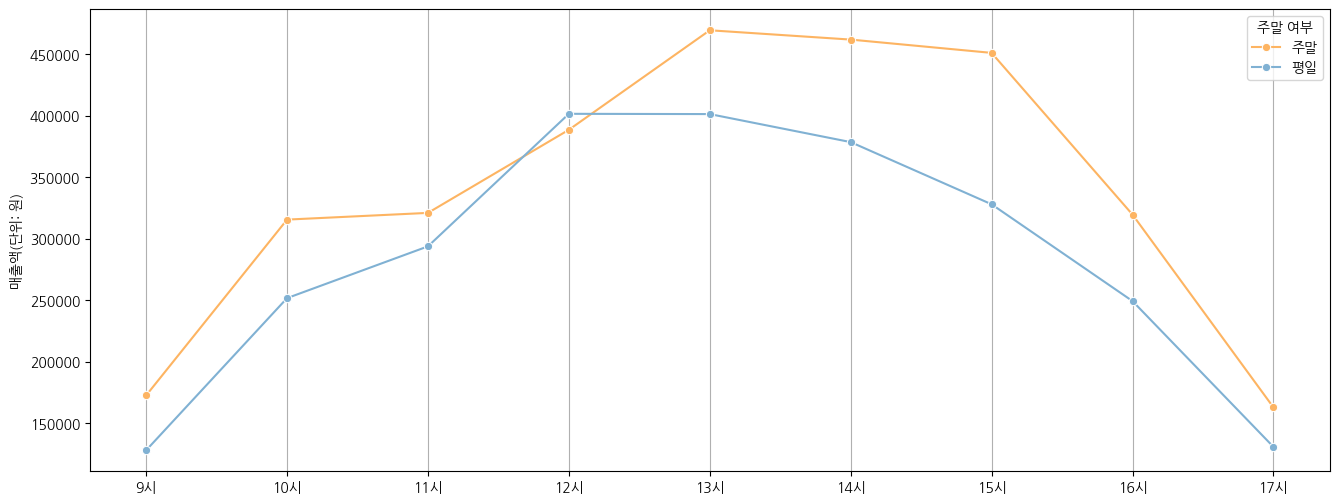

In [32]:
# 카페 시간대별 평일/주말 매출 변화
# 결제일, 결제시간대, 주말 여부별로 일 매출을 먼저 합산한다.
daily_hourly_weekend_rev = cp_data_df.groupby(['결제일', '결제시간대', '주말 여부'])['매출'].sum().reset_index(name='매출')

# 일별 합계 매출을 다시 시간대와 주말 여부 기준으로 평균내어 평일/주말의 시간대별 평균 매출을 구한다.
avg_hourly_weekend_rev = daily_hourly_weekend_rev.groupby(['결제시간대', '주말 여부'])['매출'].mean().reset_index(name='매출')

# 시간대 순서 지정
# 카테고리형으로 변환해 그래프 x축이 9시부터 18시까지 순서대로 표시되게 한다.
hour_order = ['9시', '10시', '11시', '12시', '13시', '14시', '15시', '16시', '17시', '18시']
avg_hourly_weekend_rev['결제시간대'] = pd.Categorical(avg_hourly_weekend_rev['결제시간대'], categories=hour_order, ordered=True)

# 시간대별 평일/주말 평균 매출 시각화
plt.figure(figsize=(16, 6))
sns.lineplot(data=avg_hourly_weekend_rev, x='결제시간대', y='매출', hue='주말 여부', palette=colors1, marker='o')
plt.xlabel('')
plt.ylabel('매출액(단위: 원)')
plt.grid(axis='x')
plt.show()

#### 2-3. 시간대별 평일/주말 거래 건당 평균 금액

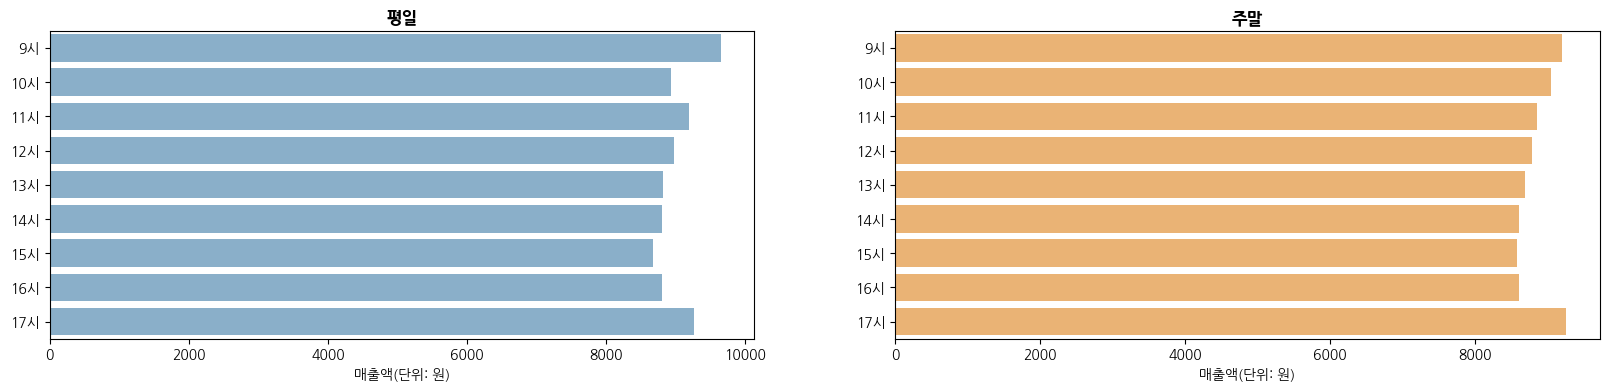

In [33]:
# 시간대별 평일/주말 거래 건당 평균 금액
# 결제시간대와 주말 여부를 기준으로 개별 거래의 평균 매출액을 계산한다.
avg_order_rev_by_hour_weekend = cp_data_df.groupby(['결제시간대', '주말 여부'])['매출'].mean().reset_index(name='매출')

# 시간대 순서 지정
# 운영 시간 순서대로 막대그래프가 정렬되도록 카테고리 순서를 지정한다.
hour_order = ['9시', '10시', '11시', '12시', '13시', '14시', '15시', '16시', '17시']
avg_order_rev_by_hour_weekend['결제시간대'] = pd.Categorical(avg_order_rev_by_hour_weekend['결제시간대'], categories=hour_order, ordered=True)

# 시간대별 평일/주말 거래 건당 평균 금액 시각화
fig, axes = plt.subplots(1, 2, figsize=(20, 4))

# 평일 평균 거래금액 그래프
ax1 = axes[0]
sns.barplot(data=avg_order_rev_by_hour_weekend.loc[avg_order_rev_by_hour_weekend['주말 여부'] == '평일'], x='매출', y='결제시간대', ax=ax1, color=colors1[1])
ax1.set_title('평일', fontsize=12, weight='bold')
ax1.set_xlabel('매출액(단위: 원)', fontsize=10)
ax1.set_ylabel('')

# 주말 평균 거래금액 그래프
ax2 = axes[1]
sns.barplot(data=avg_order_rev_by_hour_weekend.loc[avg_order_rev_by_hour_weekend['주말 여부'] == '주말'], x='매출', y='결제시간대', ax=ax2, color=colors1[0])
ax2.set_title('주말', fontsize=12, weight='bold')
ax2.set_xlabel('매출액(단위: 원)', fontsize=10)
ax2.set_ylabel('')

plt.show()

### 3. 카페 요일별 매출 추이 

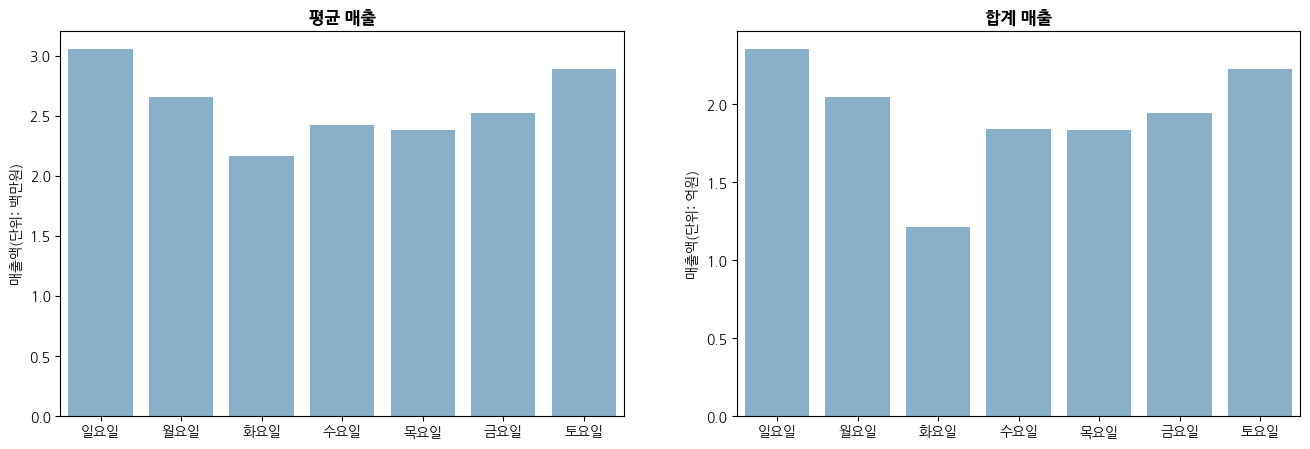

In [34]:
# 카페 요일별 매출 추이
# 요일이 그래프에서 일요일부터 토요일까지 고정된 순서로 표시되도록 순서를 지정한다.
day_order = ['일요일', '월요일', '화요일', '수요일', '목요일', '금요일', '토요일']

# 일별 요일 매출 집계
# 같은 결제일에 발생한 매출을 합산해 하루 단위 매출을 만든다.
daily_weekday_rev = cp_data_df.groupby(['결제일', '요일'])['매출'].sum().reset_index(name='매출')

# 요일별 평균 매출 집계
# 일별 매출을 요일 기준으로 평균내어 특정 요일의 일반적인 매출 수준을 확인한다.
avg_weekday_rev = daily_weekday_rev.groupby(['요일'])['매출'].mean().reset_index(name='매출')
avg_weekday_rev['요일'] = pd.Categorical(avg_weekday_rev['요일'], categories=day_order, ordered=True)

# 요일별 합계 매출 집계
# 전체 기간 동안 각 요일이 만든 총매출을 비교한다.
total_weekday_rev = cp_data_df.groupby(['요일'])['매출'].sum().reset_index(name='매출')
total_weekday_rev['요일'] = pd.Categorical(total_weekday_rev['요일'], categories=day_order, ordered=True)

# 그래프 해석을 쉽게 하기 위해 평균 매출은 백만원, 합계 매출은 억원 단위로 변환
avg_weekday_rev['매출'] = avg_weekday_rev['매출'] / 1e6
total_weekday_rev['매출'] = total_weekday_rev['매출'] / 1e8

# 요일별 평균 매출과 합계 매출 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 요일별 평균 매출액
ax1 = axes[0]
sns.barplot(data=avg_weekday_rev, x='요일', y='매출', ax=ax1, color=colors1[1])
ax1.set_title('평균 매출', fontsize=12, weight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('매출액(단위: 백만원)', fontsize=10)

# 요일별 합계 매출액
ax2 = axes[1]
sns.barplot(data=total_weekday_rev, x='요일', y='매출', ax=ax2, color=colors1[1])
ax2.set_title('합계 매출', fontsize=12, weight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('매출액(단위: 억원)', fontsize=10)

plt.show()

### 4. 계절별 매출 추이 

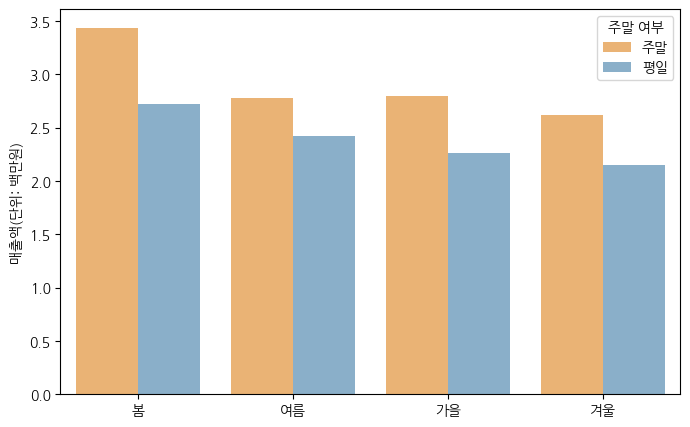

In [35]:
# 계절별 매출 추이
# 결제일, 계절, 주말 여부별로 하루 매출을 먼저 합산한다.
daily_season_weekend_rev = cp_data_df.groupby(['결제일', '계절', '주말 여부'])['매출'].sum().reset_index(name='매출')

# 계절과 주말 여부 기준으로 일평균 매출을 계산해 계절성 및 평일/주말 차이를 확인한다.
avg_season_weekend_rev = daily_season_weekend_rev.groupby(['계절', '주말 여부'])['매출'].mean().reset_index(name='매출')

# 계절 순서 지정
# 그래프 x축이 봄, 여름, 가을, 겨울 순서로 표시되도록 카테고리 순서를 지정한다.
season_order = ['봄', '여름', '가을', '겨울']
avg_season_weekend_rev['계절'] = pd.Categorical(avg_season_weekend_rev['계절'], categories=season_order, ordered=True)

# 그래프 해석을 쉽게 하기 위해 매출 단위를 원에서 백만원으로 변환
avg_season_weekend_rev['매출'] = avg_season_weekend_rev['매출'] / 1e6

# 계절별 평일/주말 일평균 매출 시각화
plt.figure(figsize=(8, 5))
sns.barplot(data=avg_season_weekend_rev, x='계절', y='매출', hue='주말 여부', palette=colors1)
plt.xlabel('')
plt.ylabel('매출액(단위: 백만원)', fontsize=10)

plt.show()

## 1-2. 카페 메뉴와 매출 관계 분석

## 1-3. 연관성 분석

## 1-4. 방문인원단위 추정

In [36]:
# 방문 인원 단위 추정
# 결제일시가 같은 메뉴들을 한 주문 단위로 보고, 음료/방문 관련 메뉴 개수로 방문 인원 단위를 추정한다.
# 디저트, 원두, 드립백/캡슐, 사업자, MD는 방문 인원 추정에서 제외한다.
non_visit_categories = ['디저트', '싱글원두', '블렌딩원두', '드립백/캡슐', '사업자', 'MD']
visit_menu_df = cp_data_df.loc[~cp_data_df['카테고리'].isin(non_visit_categories)].copy()

# 방문 인원 추정에 사용된 카테고리 확인
visit_categories = visit_menu_df['카테고리'].unique()
print(visit_categories)

# 결제일시별 주문 메뉴 수를 방문 인원 단위로 집계
visit_unit_by_order_dt = visit_menu_df.groupby('결제일시').size().reset_index(name='방문 인원 단위')

# 방문 인원 단위별 방문 수 집계
visitor_unit_counts = (
    visit_unit_by_order_dt['방문 인원 단위']
    .value_counts()
    .sort_index()
    .reset_index(name='방문 수')
    .rename(columns={'방문 인원 단위': '인원(가정)'})
)

visitor_unit_counts

['핸드드립' '에스프레소' '시그니처' 'Basic' '비버리지' '세트']


,인원(가정),방문 수
0,1,20997
1,2,31019
2,3,7685
3,4,2214
4,5,505
5,6,120
6,7,33
7,8,15
8,9,4
9,10,2


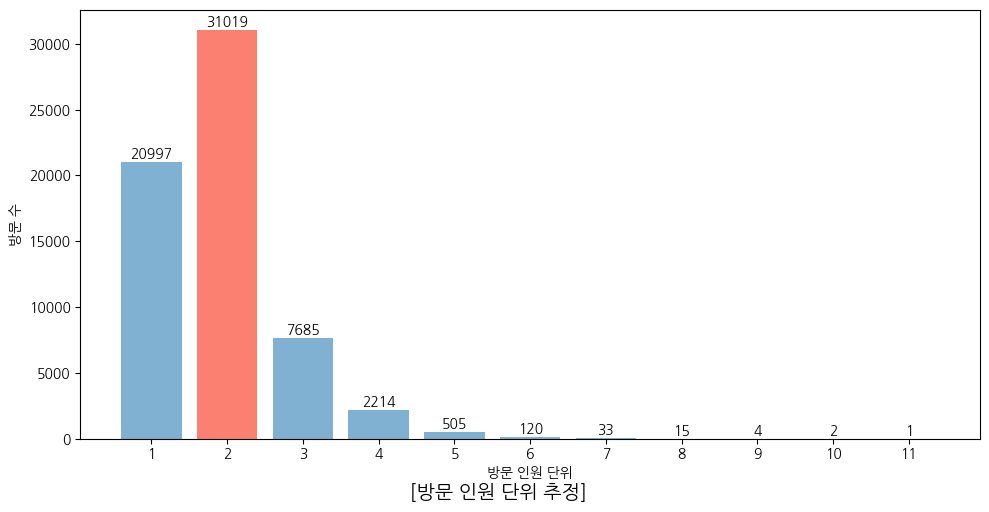

In [37]:
# 방문 인원 단위 분포 시각화
# 앞 셀에서 계산한 visitor_unit_counts를 사용해 하드코딩 없이 그래프를 생성한다.
visitor_unit_plot_df = visitor_unit_counts.copy()

# 2인 방문 추정값은 강조색으로, 나머지는 기본색으로 표시한다.
bar_colors = [
    sns.color_palette('Set3')[3] if visitor_unit == 2 else sns.color_palette('Set3')[4]
    for visitor_unit in visitor_unit_plot_df['인원(가정)']
]

plt.figure(figsize=(10, 5))
bars = plt.bar(visitor_unit_plot_df['인원(가정)'], visitor_unit_plot_df['방문 수'], color=bar_colors)

# x축을 방문 인원 단위별로 표시한다.
plt.xticks(ticks=visitor_unit_plot_df['인원(가정)'], labels=visitor_unit_plot_df['인원(가정)'])

# 각 막대 위에 방문 수를 표시한다.
for bar, visit_count in zip(bars, visitor_unit_plot_df['방문 수']):
    plt.text(bar.get_x() + bar.get_width() / 2, visit_count + 300, f'{visit_count}', ha='center')

plt.xlabel('방문 인원 단위')
plt.ylabel('방문 수')
plt.title('')
plt.figtext(0.5, -0.006, ' [방문 인원 단위 추정]', fontsize=14, ha='center')

plt.tight_layout()
plt.show()